# Multi-Factor Correlation Analysis
Computes pairwise correlation between technical factors across multiple months for HS300 constituents, then visualises the average correlation matrix as a heatmap.

In [1]:
from atrader import *
from pandas import DataFrame
from neutralization import standardization
from MAD_factor import extreme_MAD
import matplotlib.pyplot as plt
import seaborn as sns

## Helper: Factor Correlation
Applies MAD extreme-value removal and standardisation before computing the correlation matrix.

In [2]:
def factor_corr(factors: DataFrame):
    factors = factors.set_index('code')
    factors_process = standardization(extreme_MAD(factors.fillna(0)))
    result = factors_process.fillna(0).corr()
    return result

## Configuration

In [3]:
factor_names = ['aroon_down', 'cci', 'adxr', 'atr']
date = '2025-07-01'
code_list = list(get_code_list('hs300', date=date).code)

## Fetch Factor Data

In [4]:
factors_1 = get_factor_by_day(factor_list=factor_names, target_list=code_list, date='2025-02-28')
factors_2 = get_factor_by_day(factor_list=factor_names, target_list=code_list, date='2025-03-31')
factors_3 = get_factor_by_day(factor_list=factor_names, target_list=code_list, date='2025-04-30')
factors_4 = get_factor_by_day(factor_list=factor_names, target_list=code_list, date='2025-05-30')

## Compute Average Correlation Matrix

In [5]:
factors_corr1 = factor_corr(factors_1)
factors_corr2 = factor_corr(factors_2)
factors_corr3 = factor_corr(factors_3)
factors_corr4 = factor_corr(factors_4)

factors_corr = (factors_corr1 + factors_corr2 + factors_corr3 + factors_corr4).div(4)
factors_corr

,aroon_down,cci,adxr,atr
aroon_down,1.00000,-0.63496,-0.27978,0.01633
cci,-0.63496,1.00000,0.13848,0.02677
adxr,-0.27978,0.13848,1.00000,0.05849
atr,0.01633,0.02677,0.05849,1.00000


## Correlation Statistics

In [6]:
mean_abs = abs(factors_corr).mean()
print('mean abs corr: \n{}'.format(mean_abs))

median_abs = abs(factors_corr).median()
print('median abs corr: \n{}'.format(median_abs))

mean abs corr: 
aroon_down    0.48277
cci           0.45005
adxr          0.36919
atr           0.27540
dtype: float64
median abs corr: 
aroon_down    0.45737
cci           0.38672
adxr          0.20913
atr           0.04263
dtype: float64


## Heatmap Visualisation

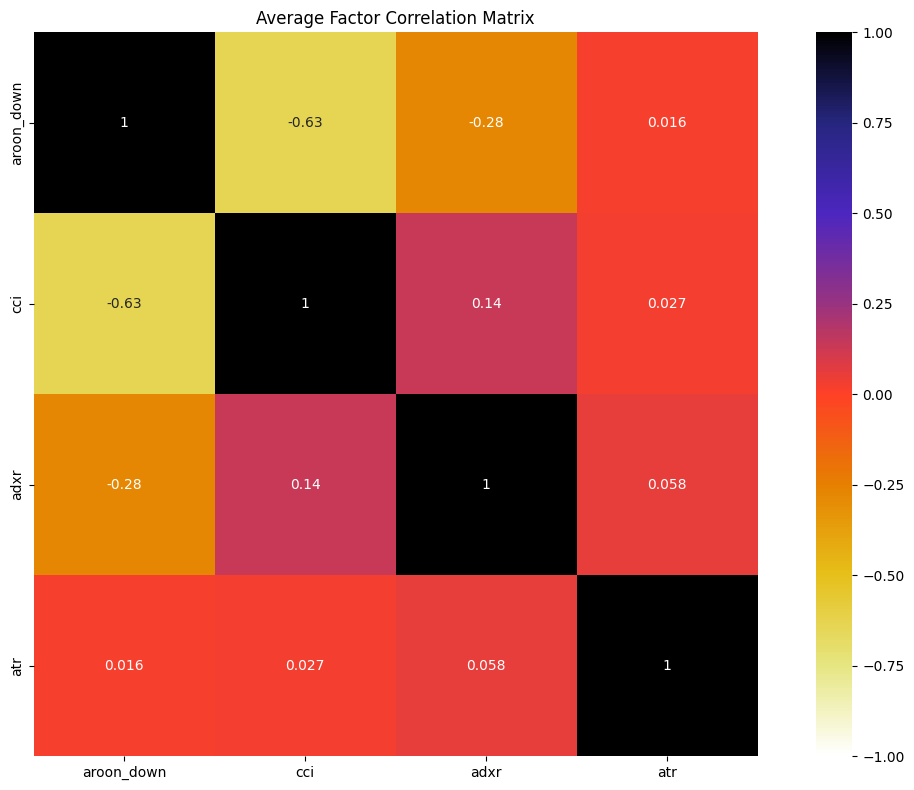

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(factors_corr, annot=True, cmap='CMRmap_r', vmin=-1, vmax=1, square=True)
plt.title('Average Factor Correlation Matrix')
plt.tight_layout()
plt.show()